Shape: (200, 5)

Null counts:
 Age           22
Salary        27
Department    10
Score         49
Experience     5
dtype: int64

Null percentage:
 Age           11.0
Salary        13.5
Department     5.0
Score         24.5
Experience     2.5
dtype: float64

df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         178 non-null    float64
 1   Salary      173 non-null    float64
 2   Department  190 non-null    object 
 3   Score       151 non-null    float64
 4   Experience  195 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.9+ KB


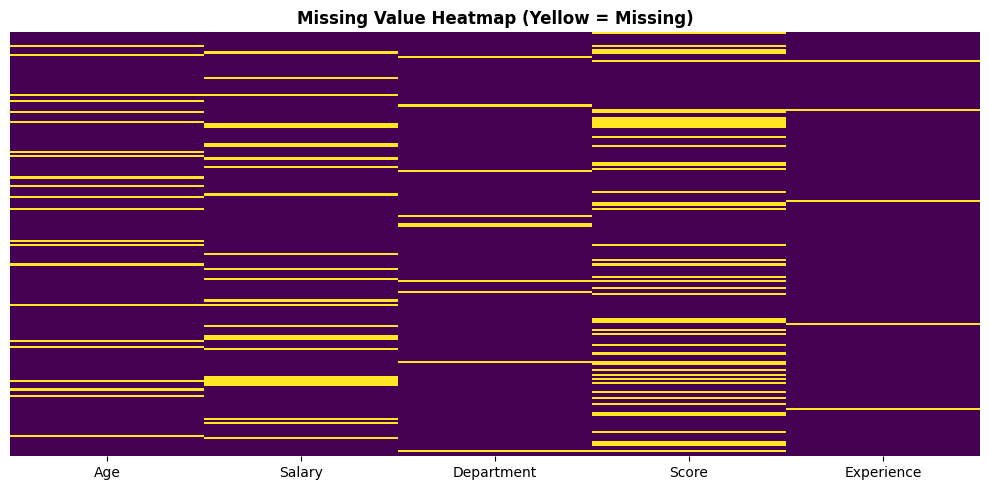

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate a real-world messy dataset
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'Age':        np.where(np.random.rand(n) < 0.1, np.nan, np.random.randint(18, 60, n).astype(float)),
    'Salary':     np.where(np.random.rand(n) < 0.15, np.nan, np.random.randint(30000, 120000, n).astype(float)),
    'Department': np.where(np.random.rand(n) < 0.08, None,   np.random.choice(['HR','Tech','Sales','Finance'], n)),  # None not np.nan
    'Score':      np.where(np.random.rand(n) < 0.2, np.nan, np.random.uniform(40, 100, n)),
    'Experience': np.where(np.random.rand(n) < 0.05, np.nan, np.random.randint(0, 20, n).astype(float)),
})

print("Shape:", df.shape)
print("\nNull counts:\n", df.isnull().sum())
print("\nNull percentage:\n", (df.isnull().sum() / len(df) * 100).round(2))
print("\ndf.info():")
df.info()

# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)', fontweight='bold')
plt.tight_layout()
plt.savefig('missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
df_original = df.copy()

# Drop rows with ANY null
df_drop_any = df.dropna()
print("Original shape:", df.shape)
print("After dropna():", df_drop_any.shape)
print(f"Rows lost: {len(df) - len(df_drop_any)}")

# Drop rows where SPECIFIC column is null
df_drop_salary = df.dropna(subset=['Salary'])
print("\nAfter dropna(subset=['Salary']):", df_drop_salary.shape)

# Drop columns with more than 15% missing
threshold = 0.15
missing_pct = df.isnull().sum() / len(df)
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
print(f"\nColumns with >15% missing: {cols_to_drop}")
df_drop_cols = df.drop(columns=cols_to_drop)
print("After dropping high-null columns:", df_drop_cols.shape)

# When to drop vs impute:
print("""
Rule of thumb:
- <5% missing  → safe to drop rows
- 5-30% missing → impute
- >30% missing  → drop the column or use advanced methods
""")

Original shape: (200, 5)
After dropna(): (107, 5)
Rows lost: 93

After dropna(subset=['Salary']): (173, 5)

Columns with >15% missing: ['Score']
After dropping high-null columns: (200, 4)

Rule of thumb:
- <5% missing  → safe to drop rows
- 5-30% missing → impute
- >30% missing  → drop the column or use advanced methods



Age — Mean imputation:
  Before: 22 nulls | Mean: 40.03
  After:  0 nulls | Mean: 40.03

Salary — Median imputation:
  Before: 27 nulls | Median: 72318.00
  After:  0 nulls | Median: 72318.00

Department — Mode imputation:
  Before: 10 nulls | Mode: HR
  After:  0 nulls


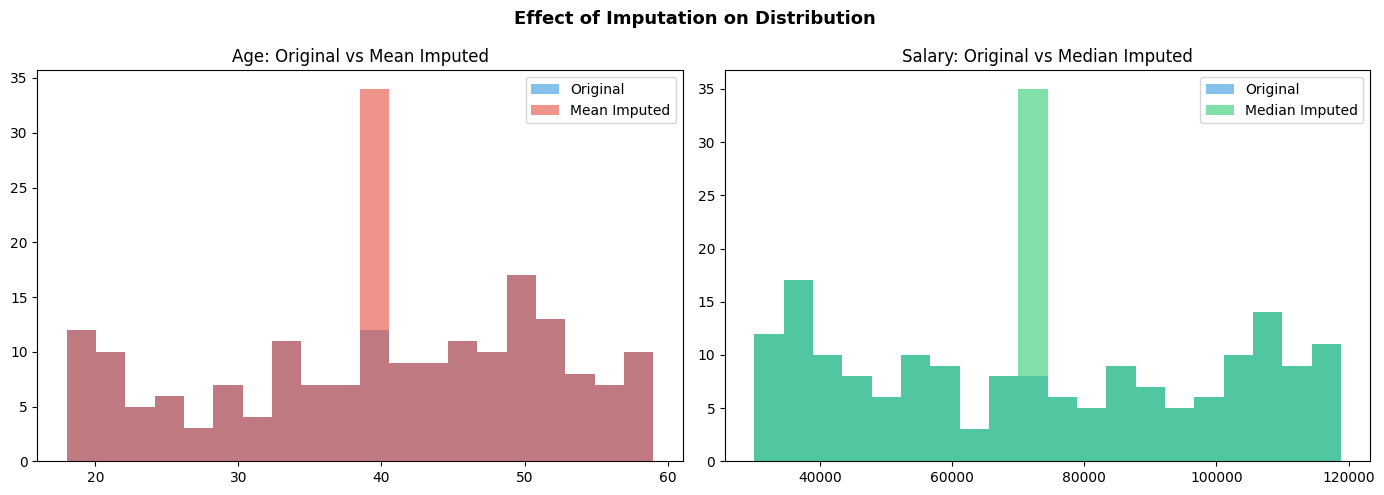

In [6]:
df = df_original.copy()

# --- Mean imputation (for normally distributed numerical columns) ---
df['Age_mean'] = df['Age'].fillna(df['Age'].mean())
print("Age — Mean imputation:")
print(f"  Before: {df['Age'].isnull().sum()} nulls | Mean: {df['Age'].mean():.2f}")
print(f"  After:  {df['Age_mean'].isnull().sum()} nulls | Mean: {df['Age_mean'].mean():.2f}")

# --- Median imputation (better for skewed distributions) ---
df['Salary_median'] = df['Salary'].fillna(df['Salary'].median())
print("\nSalary — Median imputation:")
print(f"  Before: {df['Salary'].isnull().sum()} nulls | Median: {df['Salary'].median():.2f}")
print(f"  After:  {df['Salary_median'].isnull().sum()} nulls | Median: {df['Salary_median'].median():.2f}")

# --- Mode imputation (for categorical columns) ---
df['Department_mode'] = df['Department'].fillna(df['Department'].mode()[0])
print("\nDepartment — Mode imputation:")
print(f"  Before: {df['Department'].isnull().sum()} nulls | Mode: {df['Department'].mode()[0]}")
print(f"  After:  {df['Department_mode'].isnull().sum()} nulls")

# Visualize effect of imputation on distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Imputation on Distribution', fontsize=13, fontweight='bold')

axes[0].hist(df['Age'].dropna(), bins=20, alpha=0.6, color='#3498db', label='Original')
axes[0].hist(df['Age_mean'], bins=20, alpha=0.6, color='#e74c3c', label='Mean Imputed')
axes[0].set_title('Age: Original vs Mean Imputed')
axes[0].legend()

axes[1].hist(df['Salary'].dropna(), bins=20, alpha=0.6, color='#3498db', label='Original')
axes[1].hist(df['Salary_median'], bins=20, alpha=0.6, color='#2ecc71', label='Median Imputed')
axes[1].set_title('Salary: Original vs Median Imputed')
axes[1].legend()

plt.tight_layout()
plt.savefig('imputation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Original time series:
         Date  Sales  Temp
0 2024-01-01  100.0  22.0
1 2024-01-02    NaN   NaN
2 2024-01-03    NaN  24.0
3 2024-01-04  130.0   NaN
4 2024-01-05    NaN   NaN
5 2024-01-06  150.0  27.0
6 2024-01-07    NaN   NaN
7 2024-01-08  170.0  29.0
8 2024-01-09    NaN   NaN
9 2024-01-10  190.0  31.0

After Forward Fill:
         Date  Sales  Temp
0 2024-01-01  100.0  22.0
1 2024-01-02  100.0  22.0
2 2024-01-03  100.0  24.0
3 2024-01-04  130.0  24.0
4 2024-01-05  130.0  24.0
5 2024-01-06  150.0  27.0
6 2024-01-07  150.0  27.0
7 2024-01-08  170.0  29.0
8 2024-01-09  170.0  29.0
9 2024-01-10  190.0  31.0

After Backward Fill:
         Date  Sales  Temp
0 2024-01-01  100.0  22.0
1 2024-01-02  130.0  24.0
2 2024-01-03  130.0  24.0
3 2024-01-04  130.0  27.0
4 2024-01-05  150.0  27.0
5 2024-01-06  150.0  27.0
6 2024-01-07  170.0  29.0
7 2024-01-08  170.0  29.0
8 2024-01-09  190.0  31.0
9 2024-01-10  190.0  31.0


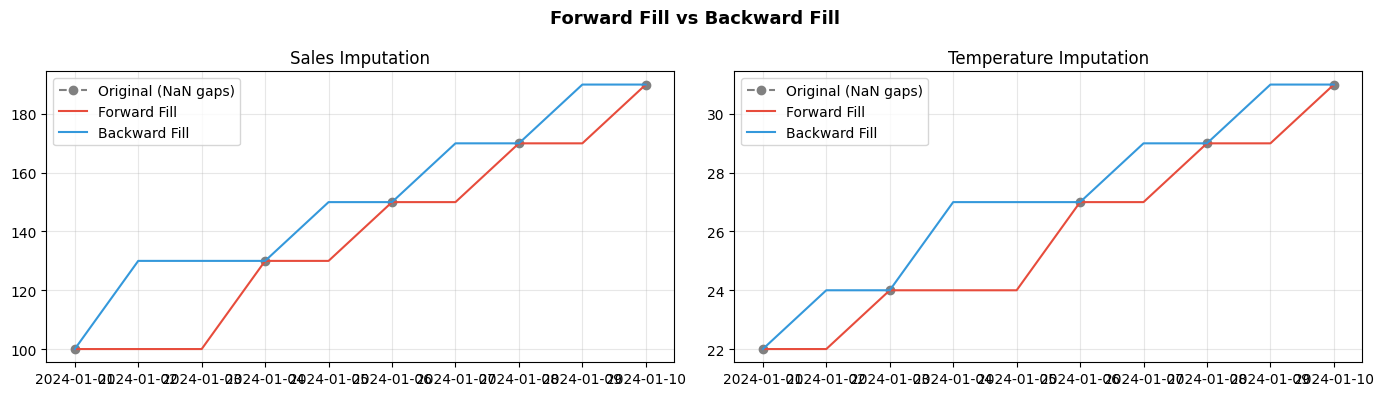

In [7]:
# ffill/bfill make sense for time-series or ordered data
# where the previous/next value is a reasonable estimate

ts_data = pd.DataFrame({
    'Date':  pd.date_range('2024-01-01', periods=10, freq='D'),
    'Sales': [100, np.nan, np.nan, 130, np.nan, 150, np.nan, 170, np.nan, 190],
    'Temp':  [22.0, np.nan, 24.0, np.nan, np.nan, 27.0, np.nan, 29.0, np.nan, 31.0]
})

print("Original time series:\n", ts_data)

# Forward fill — carry last known value forward
ts_ffill = ts_data.copy()
ts_ffill['Sales'] = ts_ffill['Sales'].ffill()
ts_ffill['Temp']  = ts_ffill['Temp'].ffill()
print("\nAfter Forward Fill:\n", ts_ffill)

# Backward fill — use next known value to fill back
ts_bfill = ts_data.copy()
ts_bfill['Sales'] = ts_bfill['Sales'].bfill()
ts_bfill['Temp']  = ts_bfill['Temp'].bfill()
print("\nAfter Backward Fill:\n", ts_bfill)

# Visualize ffill vs bfill
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Forward Fill vs Backward Fill', fontsize=13, fontweight='bold')

axes[0].plot(ts_data['Date'], ts_data['Sales'], 'o--', color='gray', label='Original (NaN gaps)')
axes[0].plot(ts_ffill['Date'], ts_ffill['Sales'], '-', color='#e74c3c', label='Forward Fill')
axes[0].plot(ts_bfill['Date'], ts_bfill['Sales'], '-', color='#3498db', label='Backward Fill')
axes[0].set_title('Sales Imputation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts_data['Date'], ts_data['Temp'], 'o--', color='gray', label='Original (NaN gaps)')
axes[1].plot(ts_ffill['Date'], ts_ffill['Temp'], '-', color='#e74c3c', label='Forward Fill')
axes[1].plot(ts_bfill['Date'], ts_bfill['Temp'], '-', color='#3498db', label='Backward Fill')
axes[1].set_title('Temperature Imputation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ffill_bfill.png', dpi=150, bbox_inches='tight')
plt.show()

Before KNN imputation:
Age           22
Salary        27
Score         49
Experience     5
dtype: int64

After KNN imputation:
Age           0
Salary        0
Score         0
Experience    0
dtype: int64


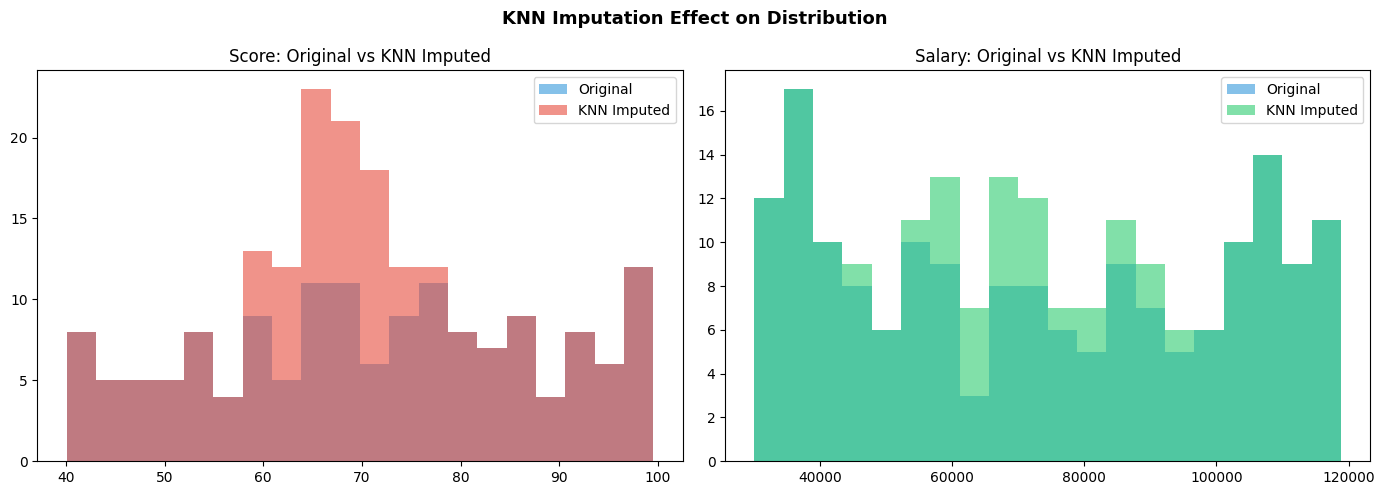


--- Imputation Strategy Comparison ---
Method               Age Nulls    Salary Nulls   Score Nulls
------------------------------------------------------------
Original             22           27             49
Mean/Median/Mode     0            0              0
KNN (k=5)            0            0              0


In [8]:
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np

df = df_original.copy()

# KNN imputation works only on numerical columns
# It finds K nearest neighbors and uses their average to fill missing values
num_cols = ['Age', 'Salary', 'Score', 'Experience']
df_num = df[num_cols].copy()

print("Before KNN imputation:")
print(df_num.isnull().sum())

knn_imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_num),
    columns=num_cols
)

print("\nAfter KNN imputation:")
print(df_imputed.isnull().sum())

# Compare distributions before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KNN Imputation Effect on Distribution', fontsize=13, fontweight='bold')

axes[0].hist(df['Score'].dropna(), bins=20, alpha=0.6,
             color='#3498db', label='Original')
axes[0].hist(df_imputed['Score'], bins=20, alpha=0.6,
             color='#e74c3c', label='KNN Imputed')
axes[0].set_title('Score: Original vs KNN Imputed')
axes[0].legend()

axes[1].hist(df['Salary'].dropna(), bins=20, alpha=0.6,
             color='#3498db', label='Original')
axes[1].hist(df_imputed['Salary'], bins=20, alpha=0.6,
             color='#2ecc71', label='KNN Imputed')
axes[1].set_title('Salary: Original vs KNN Imputed')
axes[1].legend()

plt.tight_layout()
plt.savefig('knn_imputation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary comparison table
print("\n--- Imputation Strategy Comparison ---")
print(f"{'Method':<20} {'Age Nulls':<12} {'Salary Nulls':<14} {'Score Nulls'}")
print("-" * 60)
print(f"{'Original':<20} {df['Age'].isnull().sum():<12} {df['Salary'].isnull().sum():<14} {df['Score'].isnull().sum()}")
print(f"{'Mean/Median/Mode':<20} {'0':<12} {'0':<14} {'0'}")
print(f"{'KNN (k=5)':<20} {'0':<12} {'0':<14} {'0'}")